# 📊 Credit Risk - Advanced EDA
This notebook provides a deep dive into the credit risk dataset with professional visualizations.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Setting a professional theme
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 8)
plt.rcParams["font.family"] = "sans-serif"

df = pd.read_csv('../data/processed/credit_risk_cleaned.csv')
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
1,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
2,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
3,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
4,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2


## 1. Loan Status Distribution
Target variable: `loan_status` (1 = Default, 0 = Non-Default)

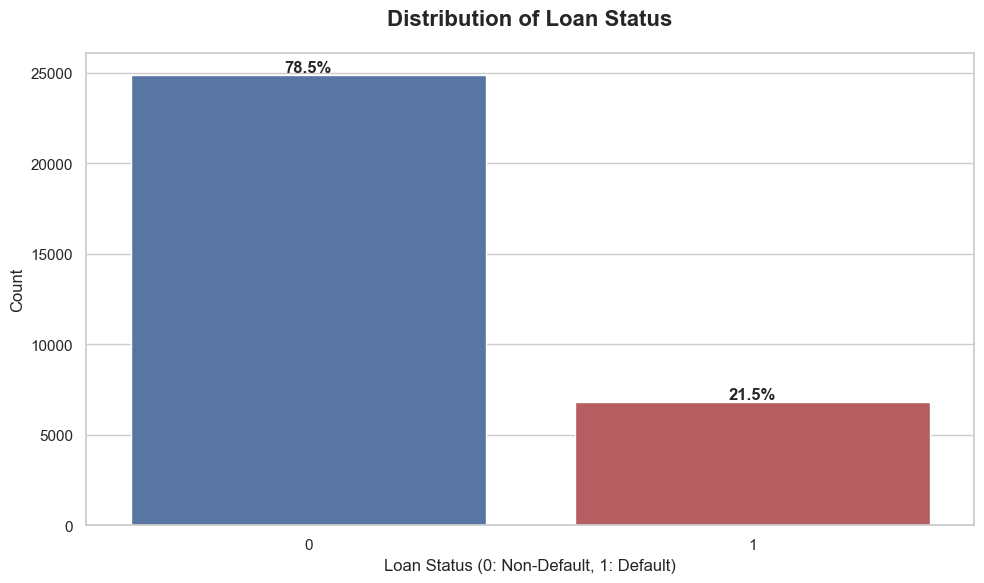

In [5]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='loan_status', data=df, hue='loan_status', palette=['#4C72B0', '#C44E52'], legend=False)

# Adding percentage labels
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Distribution of Loan Status', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Loan Status (0: Non-Default, 1: Default)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.show()

## 2. Advanced Global Pair Plot
Exploring relationships between key financial metrics with transparency and markers.

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Library/Frameworks/Python.f

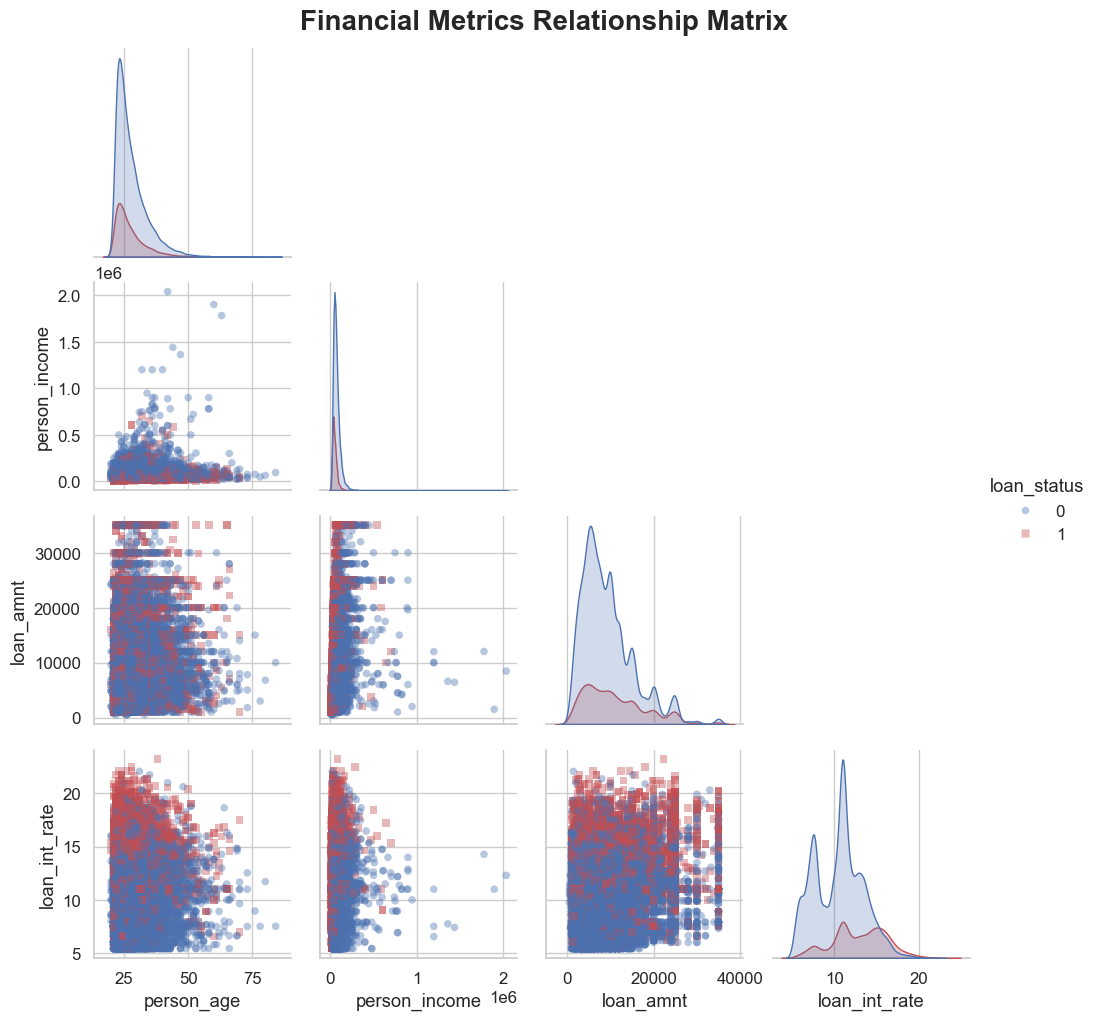

In [6]:
cols = ['person_age', 'person_income', 'loan_amnt', 'loan_int_rate', 'loan_status']
sns.set_context("notebook", font_scale=1.1)

g = sns.pairplot(
    df[cols],
    hue='loan_status',
    palette={0: "#4C72B0", 1: "#C44E52"},
    diag_kind='kde',
    markers=["o", "s"],
    plot_kws={'alpha': 0.4, 's': 30, 'edgecolor': 'none'},
    corner=True,
    grid_kws={'despine': True}
)

g.fig.suptitle('Financial Metrics Relationship Matrix', fontsize=20, fontweight='bold', y=1.02)
plt.show()

## 3. Correlation Heatmap
Understanding linear relationships between numerical features.

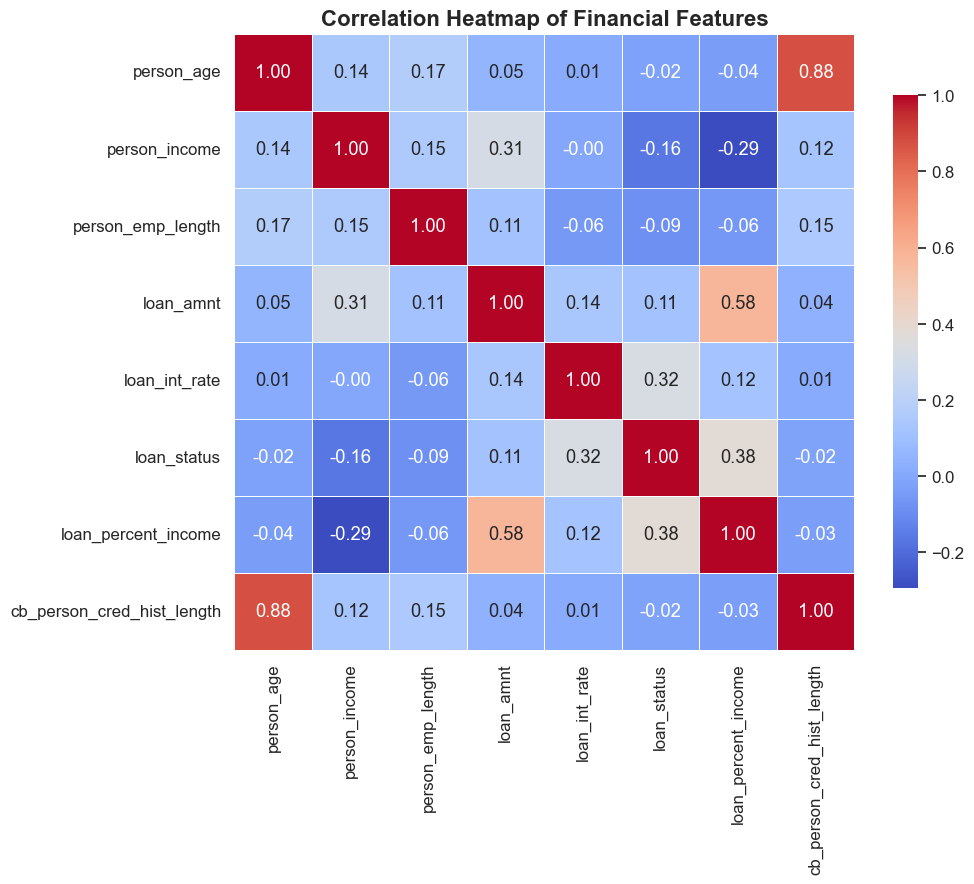

In [7]:
plt.figure(figsize=(10, 8))
numeric_cols = df.select_dtypes(include=['number']).columns
corr = df[numeric_cols].corr()
mask = corr.corr() > 0.9 # Optional mask for high correlations
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, cbar_kws={"shrink": .8})
plt.title('Correlation Heatmap of Financial Features', fontsize=16, fontweight='bold')
plt.show()